In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
import fitsio
import scipy.spatial.transform as trans
from matplotlib.patches import Rectangle
from scipy.spatial import cKDTree

In [3]:
def Poisson(N, k):
    #nexp is the expectation CiC
    #k is the measured CiC whose probability you're querying
    if k == 0:
        return np.exp(-N)
    else:
        product = 1
        for i in np.arange(1,k+1):
            product = product * N / i
        p = product*np.exp(-N)
        return p

def raDecToUnitSphere(a, d):
    a = a*np.pi/180
    d = d*np.pi/180
    x = np.cos(a)*np.cos(d)
    y = np.sin(a)*np.cos(d)
    z = np.sin(d)
    return [np.array([x[i],y[i],z[i],1]) for i in range(len(a))]
    #return np.array([x,y,z,1])
    
'''def raDecToUnitSphere(radec):
    a = [radec[i][0] for i in range(len(radec))]
    d = [radec[i][1] for i in range(len(radec))]
    a = a*np.pi/180
    d = d*np.pi/180
    x = np.cos(a)*np.cos(d)
    y = np.sin(a)*np.cos(d)
    z = np.sin(d)
    return [np.array([x[i],y[i],z[i],1]) for i in range(len(a))]
    #return np.array([x,y,z,1])'''

def UnitSphereToRaDec(UScoord):
    x,y,z = [UScoord[i][0] for i in range(len(UScoord))],[UScoord[i][1] for i in range(len(UScoord))],[UScoord[i][2] for i in range(len(UScoord))]
    d = np.arcsin(z)
    arg = x/np.cos(d)
    def ceiling(x):
        if x > 1:
            x = 1
        if x < -1:
            x = -1
        return x
    arg = [ceiling(arg[i]) for i in range(len(arg))]
    a = np.arccos(arg)*180/np.pi
    d = d*180/np.pi
    def negforarccos(a,y):
        if y < 0:
            a = - a
        return a
    a = [negforarccos(a[i],y[i]) for i in range(len(a))]
    return [np.array([a[i], d[i]]) for i in range(len(a))] 

def UnitSphereToRaDecPosRA(UScoord):
    x,y,z = [UScoord[i][0] for i in range(len(UScoord))],[UScoord[i][1] for i in range(len(UScoord))],[UScoord[i][2] for i in range(len(UScoord))]
    d = np.arcsin(z)
    arg = x/np.cos(d)
    def ceiling(x):
        if x > 1:
            x = 1
        if x < -1:
            x = -1
        return x
    arg = [ceiling(arg[i]) for i in range(len(arg))]
    a = np.arccos(arg)*180/np.pi
    d = d*180/np.pi
    def negforarccos(a,y):
        if y < 0:
            a = - a + 360
        return a
    a = [negforarccos(a[i],y[i]) for i in range(len(a))]
    return [np.array([a[i], d[i]]) for i in range(len(a))] 

def rotation(coord, phi1, phi2,r):
    #phi1, phi2: rotation angles in degrees
    #phi1, phi2 should be the coordinates of the center of the rosettes in Cartesian coordinates
    return r.apply(coord[:3])

def revrotation(coord, phi1, phi2,r):
    return r.apply(coord[:3])
    
def findAvgN(ralim,declim,table):
    #take an astropy table of galaxies to count, from RANDOMS
    #find average counts in cells in some angular region
    ramin = 130
    ramax = 223
    decmin = -5.25
    decmax = 3.75
    #make table with these cuts
    tablecut = table[(table[ra] > ramin)&(table[ra] < ramax)&(table[dec] > decmin)&(table[dec] < decmax)]
    N = len(tablecut)
    #approximate as flat
    A = (ramax - ramin)*(decmax - decmin)
    return N/A

def binomialCutoff(cutoffP, avgN):
    #convert cutoff probability to cutoff N_CiC
    pint = 0
    k = -1
    while pint < cutoffP:
        k += 1
        pint += Poisson(avgN, k)
    return k
def findHoles(randtable, Nmin, rotcoord, sidelength, stepsize):
    phi1 = rotcoord[0]
    phi2 = rotcoord[1]
    r = trans.Rotation.from_euler('zy',[phi1,phi2],degrees=True)
    #convert cutoff probability to cutoff N_CiC
    #sidelength: 1/2 side length of square area to analyze
    nsteps = int(sidelength/stepsize)
    #print("Minimum counts in cell required " + str(Nmin))
    randtable['UScoord'] = raDecToUnitSphere(randtable['RA'],randtable['DEC'])
    randtable['UScoord_rot'] = [rotation(randtable['UScoord'][i],*rotcoord,r) for i in range(len(randtable))]
    randtable['RaDec_rot'] = UnitSphereToRaDec(randtable['UScoord_rot'])
    #print(randtable['RaDec_rot'])
    maskedcells = []
    #print(maskedcells)
    #coordinates of the left lower point of a square
    ras = np.arange(-nsteps*stepsize, (nsteps+1)*stepsize, step = stepsize)
    decs = np.arange(-nsteps*stepsize, (nsteps+1)*stepsize, step = stepsize)
    for i in range(len(ras)):
        for j in range(len(decs)):
            randtablecut = randtable[([randtable['RaDec_rot'][k][0] for k in range(len(randtable))] >= ras[i])& \
                                     ([randtable['RaDec_rot'][k][0] for k in range(len(randtable))] < ras[i] + stepsize)& \
                              ([randtable['RaDec_rot'][k][1] for k in range(len(randtable))] >= decs[j])& \
                                     ([randtable['RaDec_rot'][k][1] for k in range(len(randtable))] < decs[j] + stepsize)]
            ncic = len(randtablecut)
            #print(ncic)
            if ncic < Nmin: 
                maskedcells.append([i,j])
    return maskedcells

def holeConjunction(maskedcells,stepsize):
    ANDmask = []
    for m in range(len(maskedcells)):
        i = maskedcells[m][0]
        j = maskedcells[m][1]
        if ([i,j+1] in maskedcells) or ([i,j-1] in maskedcells) \
                or ([i+1,j] in maskedcells) or ([i-1,j] in maskedcells):
            ANDmask.append(maskedcells[m])
    return ANDmask    

def holeCenters(andmask, rotcoord, sidelength, stepsize):
    phi1 = rotcoord[0]
    phi2 = rotcoord[1]
    r = trans.Rotation.from_euler('yz',[-phi2,-phi1],degrees=True)
    nsteps = int(sidelength/stepsize)
    lb = -(nsteps - 0.5)*stepsize
    def holeCoord(ix):
        radecrot = [np.array([lb + ix[0]*stepsize]), np.array([lb + ix[1]*stepsize])]
        USrot = raDecToUnitSphere(*radecrot)
        US = revrotation(USrot[0], *rotcoord,r)
        return US
    holesUS = [holeCoord(andmask[i]) for i in range(len(andmask))]
    return holesUS

def generateTiles(squaresize):
    rotcoord = []
    nrows = int(180 / squaresize)
    tile_bounds_pad = []
    for i in range(nrows):
        dec = -90 + squaresize*i
        decrad = np.pi/180*dec
        ntiles = int(np.ceil(360*np.cos(decrad)/squaresize))
        tilewidth = 360/ntiles
        for j in range(ntiles):
            ra = j*tilewidth
            tile_w_pad = tilewidth + 4*cellsize/np.cos(decrad) #add padding: 2x the cell size on each side of tile
            tile_h_pad = squaresize + 4*cellsize
            tile_bound = [[ra - tilewidth/2, dec - squaresize/2],[ra+tilewidth/2,dec+squaresize/2]]
            tile_bound_pad = [[ra - tile_w_pad/2,dec-tile_h_pad/2],[ra+tile_w_pad/2,dec+tile_h_pad/2]]
            rotcoord.append([-ra,dec])
            tile_bounds_pad.append(tile_bound_pad)
    return rotcoord,tile_bounds_pad

def trimHole(hole,tile_bound):
    return (hole[0] > tile_bound[0][0])&(hole[0] <= tile_bound[1][0]) & \
    (hole[1] > tile_bound[0][1])&(hole[1] <= tile_bound[1][1])

def searchSkyForHoles(randtable, squaresize, cellsize, Nmin):
    holes = [] #hole positions in Cartesian coordinates on the unit sphere
    rotcoord,tile_bounds,tile_bounds_pad = generateTiles(squaresize,cellsize)
    tiletables = [randtable[(randtable['RA'] > tile_bounds_pad[i][0][0]) & \
                             (randtable['DEC'] > tile_bounds_pad[i][0][1]) & \
                             (randtable['RA'] <= tile_bounds_pad[i][1][0]) & \
                             (randtable['DEC'] <= tile_bounds_pad[i][0][1])] \
                                        for i in range(len(tile_bounds_pad))]
    #only include a few tiles for testing purposes
    tiletables = tiletables[16:17]
    holesinit = [findHoles(tiletables[i], Nmin, rotcoord[i], squaresize, cellsize) for i in range(len(tiletables))]
    print(holesinit)
    holeconjunction = [holeConjunction(holesinit[i],cellsize) for i in range(len(holes))]
    holecenters_untrimmed = np.array([holeCenters(holeconjunction[i],rotcoord[i],squaresize,cellsize) \
                                      for i in range(len(holeconjunction))])
    print(holecenters_untrimmed)
    holemask = [[trimHole(holecenters_untrimmed[i][j],tile_bounds[i]) for j in range(len(holecenters_untrimmed[i]))] \
                            for i in range(len(holecenters_untrimmed))]
    holecenters_trimmed = holecenters_untrimmed[holemask]
    for h in holecenters_trimmed:
        holes += h
    return holes

In [4]:
#poke around with LSS randoms
'''table1 = []
for i in np.arange(18):
    eNfile = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELG_N_'+str(i)+'_clustering.ran.fits'
    eSfile = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELG_S_'+str(i)+'_clustering.ran.fits'
    lNfile = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/LRG_N_'+str(i)+'_clustering.ran.fits'
    lSfile = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/LRG_S_'+str(i)+'_clustering.ran.fits'
    speN = Table(fitsio.read(eNfile))
    speS = Table(fitsio.read(eSfile))
    splN = Table(fitsio.read(lNfile))
    splS = Table(fitsio.read(lSfile))
    table1.append(speN)
    table1.append(speS)
    #table1.append(splN)
    #table1.append(splS)'''
    

'''    
table2 = []
for i in np.arange(14,18):
    eNfile = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELG_N_'+str(i)+'_clustering.ran.fits'
    eSfile = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELG_S_'+str(i)+'_clustering.ran.fits'
    lNfile = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/LRG_N_'+str(i)+'_clustering.ran.fits'
    lSfile = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/LRG_S_'+str(i)+'_clustering.ran.fits'
    speN = Table(fitsio.read(eNfile))
    speS = Table(fitsio.read(eSfile))
    splN = Table(fitsio.read(lNfile))
    splS = Table(fitsio.read(lSfile))
    table2.append(speN)
    table2.append(speS)
    #table2.append(splN)
    #table2.append(splS)'''


#try with Aurelio's mocks
randir = "/global/cfs/cdirs/desi/users/acarnero/CIC_mocks/Y1/fiducial/randoms/"
randtables = []
for i in np.arange(18):
    ranfile = randir+"fidran"+str(i)+"_Y1.fits"
    sp = Table(fitsio.read(ranfile))
    randtables.append(sp)
randtable = vstack(randtables)
'''
randtable = vstack(table1)

print(len(table1[0]))
print(len(randtable))'''

'\nrandtable = vstack(table1)\n\nprint(len(table1[0]))\nprint(len(randtable))'

In [5]:
squaresize = 2
cellsize = 0.01
Nmin = 10
holes = searchSkyForHoles(randtable,squaresize,cellsize,Nmin)

TypeError: generateTiles() takes 1 positional argument but 2 were given

In [5]:
randtable[:1]

RA,DEC
float64,float64
2.563238986993774,-13.765964039403194


In [9]:
randir = "/global/cfs/cdirs/desi/users/acarnero/CIC_mocks/Y1/fiducial/ELG/"
randtables = []
for i in np.arange(1):
    ranfile = randir+"fid_elg_Y1_"+str(i)+".fits"
    sp = Table(fitsio.read(ranfile))
    randtables.append(sp)
randtable = vstack(randtables)

In [10]:
randtable[:1]

RA,DEC,TRUEZ,STATUS,RSDZ,PRIORITY_INIT,PRIORITY,DESI_TARGET,NUMOBS_MORE,NUMOBS_INIT,TARGETID,BRICKID,NOBS_G,NOBS_R,NOBS_Z,MASKBITS,BGS_TARGET,MWS_TARGET,SUBPRIORITY,BRICKNAME,OBSCONDITIONS,SCND_TARGET,ZWARN
float32,float32,float32,int32,float32,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int16,int64,int64,float64,str8,int64,int64,int64
64.46006,0.5625,0.015958173,15,0.016259655,3100,3100,34,2,2,9910024,333505,4,4,6,0,0,0,0.8376303749335617,000p0000,1,0,0


44428


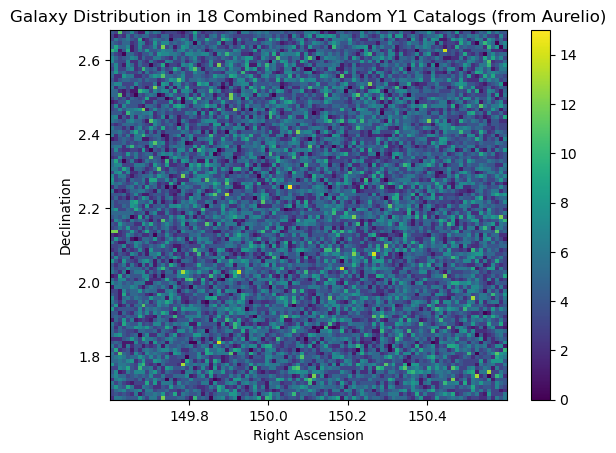

In [7]:
randoms1 = randtable
ra1 = 150.1
dec1 = 2.182
stepsize = 0.01
rotcoord = [-ra1,dec1]
sidelength = 0.5
nsteps = int(sidelength/stepsize)
cut2 = randoms1[(randoms1['RA'] > ra1-nsteps*stepsize)&(randoms1['RA']<ra1+nsteps*stepsize)&(randoms1['DEC']>dec1-nsteps*stepsize)&(randoms1['DEC']<dec1+nsteps*stepsize)]
hist1,binsy,binsx = np.histogram2d(cut2['DEC'],cut2['RA'],bins=2*nsteps)
fig, ax = plt.subplots(1)
pc = ax.pcolormesh(binsx,binsy,hist1)
cbar = plt.colorbar(pc)
plt.xlabel("Right Ascension")
plt.ylabel("Declination")
plt.title("Galaxy Distribution in 18 Combined Random Y1 Catalogs (from Aurelio)")

print(len(cut2))

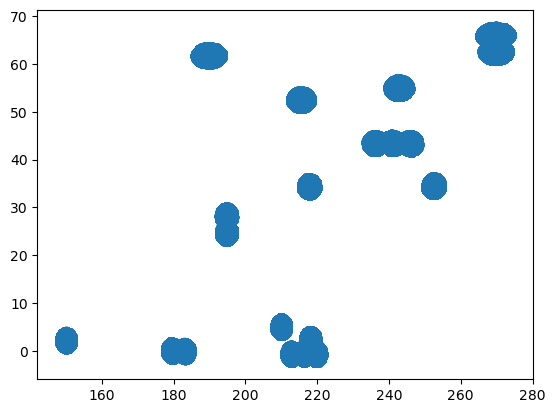

In [17]:
plt.scatter(randtable['RA'],randtable['DEC'])

mean count in (0.012deg)^2 cell: 4.62890625


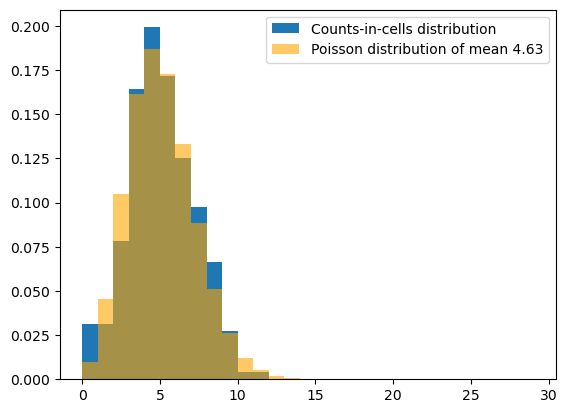

In [93]:
histlist = hist1.flatten()
N = np.average(histlist)
print("mean count in ("+str(stepsize)+"deg)^2 cell: "+str(N))
plt.figure()
plt.hist(histlist, density=True,bins=np.arange(30),label = "Counts-in-cells distribution")
x = np.arange(25)
px = [Poisson(N,x_i) for x_i in x]
plt.bar(x,px,color='orange',align='edge',width=1,alpha=0.6,label='Poisson distribution of mean '+str(np.round(N,2)))
plt.legend()

In [94]:
randtable = cut2
Nmin = 1 #should be ra, -dec
mask1 = findHoles(randtable, Nmin, rotcoord, sidelength, stepsize)

Minimum counts in cell required 1
[-0.00160689 -0.00157666 -0.00137296 ...  0.00146911  0.00069604
 -0.00074593]
[0.99999871 0.99999876 0.99999906 ... 0.99999892 0.99999976 0.99999972]


In [95]:
andmask = holeConjunction(mask1,stepsize)

In [96]:
xbins = np.arange(-stepsize*nsteps, stepsize*(nsteps+1),stepsize)
ybins = np.arange(-stepsize*nsteps, stepsize*(nsteps+1),stepsize)

cut2 = randoms1[(randoms1['RA'] > ra1-nsteps*stepsize)&(randoms1['RA']<ra1+nsteps*stepsize)&(randoms1['DEC']>dec1-nsteps*stepsize)&(randoms1['DEC']<dec1+nsteps*stepsize)]
cut2['UScoord'] = raDecToUnitSphere(cut2['RA'],cut2['DEC'])
cut2['UScoord_rot'] = [rotation(cut2['UScoord'][i],*rotcoord) for i in range(len(cut2))]
cut2['RaDec_rot'] = UnitSphereToRaDec(cut2['UScoord_rot'])
hist1,binsy,binsx = np.histogram2d([cut2['RaDec_rot'][i][1] for i in range(len(cut2))],
                                   [cut2['RaDec_rot'][i][0] for i in range(len(cut2))],bins=[ybins,xbins])

[-0.00160689 -0.00157666 -0.00137296 ...  0.00146911  0.00069604
 -0.00074593]
[0.99999871 0.99999876 0.99999906 ... 0.99999892 0.99999976 0.99999972]


Text(0.5, 1.0, 'ELG Distribution in 18 Combined Random LSS SV3 Catalogs (Cell Size 0.012)')

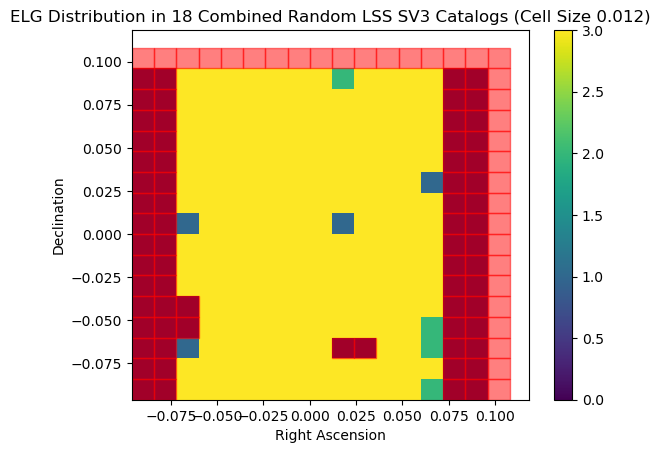

In [97]:
fig, ax = plt.subplots(1)
pc = ax.pcolormesh(binsx,binsy,hist1,vmax=3)
cbar = plt.colorbar(pc)

for i in range(len(andmask)):
    #coord = [andmask[i][0]*stepsize - stepsize*nsteps,andmask[i][1]*stepsize -stepsize*nsteps]
    coord = [mask1[i][0]*stepsize - stepsize*nsteps, mask1[i][1]*stepsize -stepsize*nsteps]
    rect = Rectangle(coord,stepsize,stepsize,color='r',alpha=0.5)
    ax.add_patch(rect)
plt.xlabel("Right Ascension")
plt.ylabel("Declination")
plt.title("ELG Distribution in 18 Combined Random LSS SV3 Catalogs (Cell Size "+str(stepsize)+")")

[0.7567736  0.75698304 0.75719248 0.75740191 0.75761135 0.75782079
 0.75803023 0.75823967 0.75844911 0.75865855 0.75886799 0.75907743
 0.75928687 0.75949631 0.75970575 0.75991519 0.76012463 0.75677389
 0.75698333 0.75719277 0.75740221 0.75761164 0.75782108 0.75803052
 0.75823996 0.7584494  0.75865884 0.75886828 0.75907772 0.75928716
 0.7594966  0.75970604 0.75991548 0.76012492 0.75740245 0.75761189
 0.76012517 0.76012537 0.76012554 0.76012567 0.76012575 0.76012579
 0.76012579 0.7571936  0.76012575 0.75719351 0.76012567 0.76012554
 0.76012537 0.76012517 0.75677389 0.75698333 0.75719277 0.75740221
 0.75761164 0.75782108 0.75803052 0.75823996 0.7584494  0.75865884
 0.75886828 0.75907772 0.75928716 0.7594966  0.75970604 0.75991548
 0.76012492 0.7567736  0.75698304 0.75719248 0.75740191 0.75761135
 0.75782079 0.75803023 0.75823967 0.75844911 0.75865855 0.75886799
 0.75907743 0.75928687 0.75949631 0.75970575 0.75991519 0.76012463
 0.75677326 0.7569827  0.75719214 0.75740158 0.75761102 0.7578

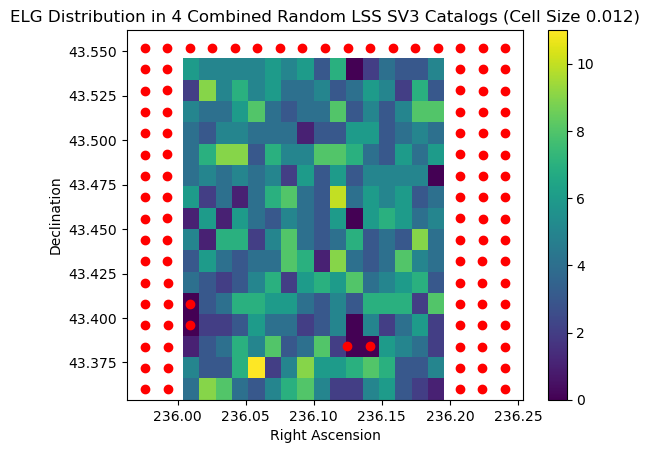

In [98]:
#check holeCenters are in the right place after rotating back

cut2 = randoms1[(randoms1['RA'] > ra1-nsteps*stepsize)&(randoms1['RA']<ra1+nsteps*stepsize)&(randoms1['DEC']>dec1-nsteps*stepsize)&(randoms1['DEC']<dec1+nsteps*stepsize)]
hist1,binsy,binsx = np.histogram2d(cut2['DEC'],cut2['RA'],bins=2*nsteps)
fig, ax = plt.subplots(1)
pc = ax.pcolormesh(binsx,binsy,hist1)
cbar = plt.colorbar(pc)
plt.xlabel("Right Ascension")
plt.ylabel("Declination")
plt.title("ELG Distribution in 4 Combined Random LSS SV3 Catalogs (Cell Size "+str(stepsize)+")")


holecentersUS = holeCenters(andmask, rotcoord, sidelength, stepsize)
holecenters = UnitSphereToRaDecPosRA(holecentersUS)

plt.scatter([holecenters[i][0] for i in range(len(holecenters))],
            [holecenters[i][1] for i in range(len(holecenters))],color='red')

## Poke around to try to figure out difference between Y1 and EDR holes in randoms ##

In [8]:
#plots to make: 
#plots to make: 
#same patch of sky in Y1, EDR for ELGs
# '' ............................ QSOs
#same patch of sky in 'noveto' catalogs
ra1 = 150.1
dec1 = 2.182
stepsize = 0.01
sidelength = 0.5
nsteps = int(sidelength/stepsize)

#ELG clustering, EDR
table1 = []
edrfulldir = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/full/'
for i in np.arange(18):
    file = edrfulldir +'ELG_'+str(i)+'_full.ran.fits'
    #eSfile = edrfulldir + 'ELG_S_'+str(i)+'_full.ran.fits'
    sp = Table(fitsio.read(file))
    spcut = sp[(sp['RA'] > ra1-nsteps*stepsize)&(sp['RA']<ra1+nsteps*stepsize)&(sp['DEC']>dec1-nsteps*stepsize)&(sp['DEC']<dec1+nsteps*stepsize)]
    #speS = Table(fitsio.read(eSfile))
    table1.append(spcut)
    #table1.append(speS)
    #table1.append(splN)
    #table1.append(splS)

elgEDR = vstack(table1)

(2.2, 2.4)

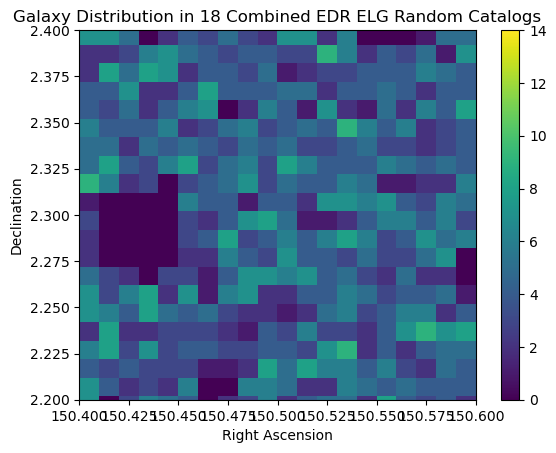

In [9]:
cut2 = elgEDR
hist1,binsy,binsx = np.histogram2d(cut2['DEC'],cut2['RA'],bins=2*nsteps)
fig, ax = plt.subplots(1)
pc = ax.pcolormesh(binsx,binsy,hist1)
cbar = plt.colorbar(pc)
plt.xlabel("Right Ascension")
plt.ylabel("Declination")
plt.title("Galaxy Distribution in 18 Combined EDR ELG Random Catalogs")
plt.savefig("figsholes/elgEDR.png")
plt.xlim(150.4,150.6)
plt.ylim(2.2,2.4)

In [8]:
ra1 = 150.1
dec1 = 2.182
stepsize = 0.01
sidelength = 0.5
nsteps = int(sidelength/stepsize)

#ELG clustering, Y1
table2 = []
y1dir = '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/'
for i in np.arange(18):
    efile = y1dir + 'ELG_LOPnotqso_'+str(i)+'_full.ran.fits'
    sp = Table(fitsio.read(efile))
    spcut = sp[(sp['RA'] > ra1-nsteps*stepsize)&(sp['RA']<ra1+nsteps*stepsize)&(sp['DEC']>dec1-nsteps*stepsize)&(sp['DEC']<dec1+nsteps*stepsize)]
    table2.append(spcut)
    print("added one catalog to table \r")
    print("... \r")

elgY1 = vstack(table2)

added one catalog to table 
... 
added one catalog to table 
... 
added one catalog to table 
... 
added one catalog to table 
... 
added one catalog to table 
... 
added one catalog to table 
... 
added one catalog to table 
... 
added one catalog to table 
... 
added one catalog to table 
... 
added one catalog to table 
... 
added one catalog to table 
... 
added one catalog to table 
... 
added one catalog to table 
... 
added one catalog to table 
... 
added one catalog to table 
... 
added one catalog to table 
... 
added one catalog to table 
... 
added one catalog to table 
... 


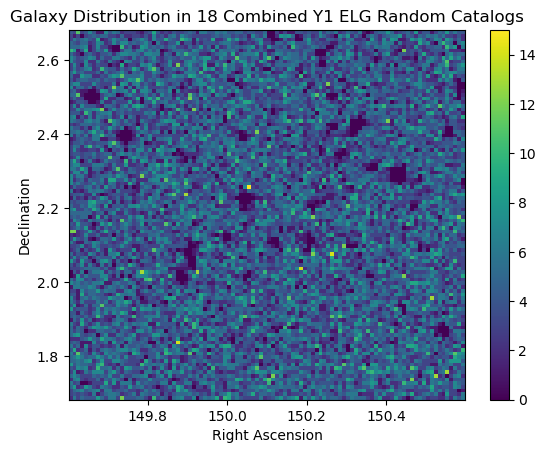

In [9]:
cut2 = elgY1
ra1 = 150.1
dec1 = 2.182
stepsize = 0.01
sidelength = 0.5
nsteps = int(sidelength/stepsize)
#cut2 = randoms1[(randoms1['RA'] > ra1-nsteps*stepsize)&(randoms1['RA']<ra1+nsteps*stepsize)&(randoms1['DEC']>dec1-nsteps*stepsize)&(randoms1['DEC']<dec1+nsteps*stepsize)]
hist1,binsy,binsx = np.histogram2d(cut2['DEC'],cut2['RA'],bins=2*nsteps)
fig, ax = plt.subplots(1)
pc = ax.pcolormesh(binsx,binsy,hist1)
cbar = plt.colorbar(pc)
plt.xlabel("Right Ascension")
plt.ylabel("Declination")
plt.title("Galaxy Distribution in 18 Combined Y1 ELG Random Catalogs")
plt.savefig("figsholes/elgY1.png")

In [4]:
#EDR for qsos
edrfulldir = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/full/'
ra1 = 150.1
dec1 = 2.182
stepsize = 0.01
sidelength = 0.5
nsteps = int(sidelength/stepsize)
table3 = []
for i in np.arange(18):
    file = edrfulldir +'QSO_'+str(i)+'_full.ran.fits'
    sp = Table(fitsio.read(file))
    spcut = sp[(sp['RA'] > ra1-nsteps*stepsize)&(sp['RA']<ra1+nsteps*stepsize)&(sp['DEC']>dec1-nsteps*stepsize)&(sp['DEC']<dec1+nsteps*stepsize)]
    #QS = Table(fitsio.read(QSfile))
    #QScut = QS[(QS['RA'] > ra1-nsteps*stepsize)&(QS['RA']<ra1+nsteps*stepsize)&(QS['DEC']>dec1-nsteps*stepsize)&(QS['DEC']<dec1+nsteps*stepsize)]
    table3.append(spcut)
    #table3.append(QScut)

qsoEDR = vstack(table3)
print(len(table3))

18


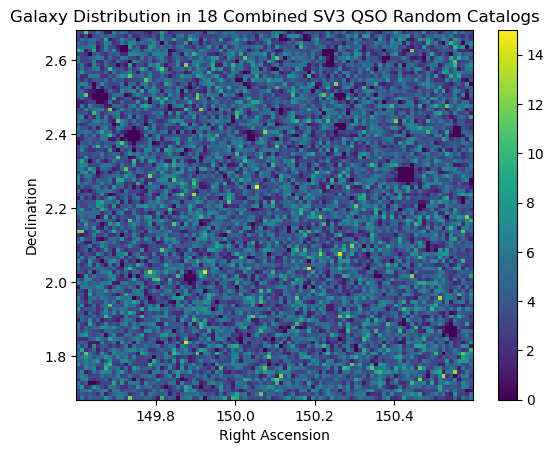

In [5]:
cut2 = qsoEDR
ra1 = 150.1
dec1 = 2.182
stepsize = 0.01
sidelength = 0.5
nsteps = int(sidelength/stepsize)
#cut2 = randoms1[(randoms1['RA'] > ra1-nsteps*stepsize)&(randoms1['RA']<ra1+nsteps*stepsize)&(randoms1['DEC']>dec1-nsteps*stepsize)&(randoms1['DEC']<dec1+nsteps*stepsize)]
hist1,binsy,binsx = np.histogram2d(cut2['DEC'],cut2['RA'],bins=2*nsteps)
fig, ax = plt.subplots(1)
pc = ax.pcolormesh(binsx,binsy,hist1)
cbar = plt.colorbar(pc)
plt.xlabel("Right Ascension")
plt.ylabel("Declination")
plt.title("Galaxy Distribution in 18 Combined SV3 QSO Random Catalogs")
plt.savefig("figsholes/qsoedr.png")

In [7]:
#Y1 for QSOs

ra1 = 150.1
dec1 = 2.182
stepsize = 0.01
sidelength = 0.5
nsteps = int(sidelength/stepsize)

#ELG clustering, Y1
y1dir = '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/'
table4 = []
for i in np.arange(18):
    qfile = y1dir + 'QSO_'+str(i)+'_clustering.ran.fits'
    sp = Table(fitsio.read(qfile))
    spcut = sp[(sp['RA'] > ra1-nsteps*stepsize)&(sp['RA']<ra1+nsteps*stepsize)&(sp['DEC']>dec1-nsteps*stepsize)&(sp['DEC']<dec1+nsteps*stepsize)]
    table4.append(spcut)

qsoY1 = vstack(table4)

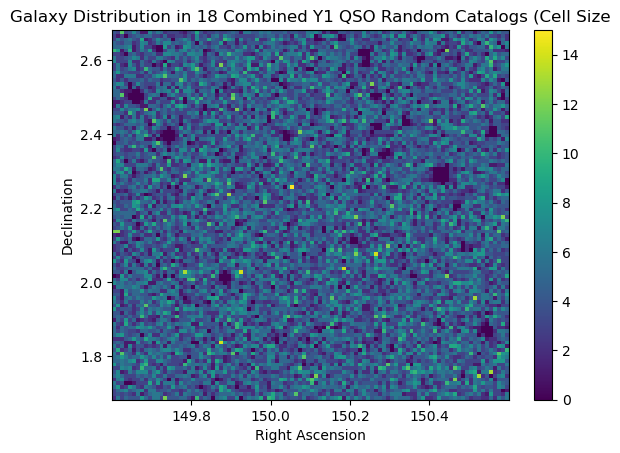

In [8]:
cut2 = qsoY1
ra1 = 150.1
dec1 = 2.182
stepsize = 0.01
sidelength = 0.5
nsteps = int(sidelength/stepsize)
#cut2 = randoms1[(randoms1['RA'] > ra1-nsteps*stepsize)&(randoms1['RA']<ra1+nsteps*stepsize)&(randoms1['DEC']>dec1-nsteps*stepsize)&(randoms1['DEC']<dec1+nsteps*stepsize)]
hist1,binsy,binsx = np.histogram2d(cut2['DEC'],cut2['RA'],bins=2*nsteps)
fig, ax = plt.subplots(1)
pc = ax.pcolormesh(binsx,binsy,hist1)
cbar = plt.colorbar(pc)
plt.xlabel("Right Ascension")
plt.ylabel("Declination")
plt.title("Galaxy Distribution in 18 Combined Y1 QSO Random Catalogs (Cell Size")
plt.savefig("figsholes/qsoY1.png")

In [15]:
#ELG clustering, EDR
table6 = []
edrfulldir = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/full/'
for i in np.arange(18):
    file = edrfulldir +'ELG_'+str(i)+'_full_noveto.ran.fits'
    #eSfile = edrfulldir + 'ELG_S_'+str(i)+'_full.ran.fits'
    sp = Table(fitsio.read(file))
    spcut = sp[(sp['RA'] > ra1-nsteps*stepsize)&(sp['RA']<ra1+nsteps*stepsize)&(sp['DEC']>dec1-nsteps*stepsize)&(sp['DEC']<dec1+nsteps*stepsize)]
    #speS = Table(fitsio.read(eSfile))
    table6.append(spcut)
    #table1.append(speS)
    #table1.append(splN)
    #table1.append(splS)

elgEDRnoveto = vstack(table6)

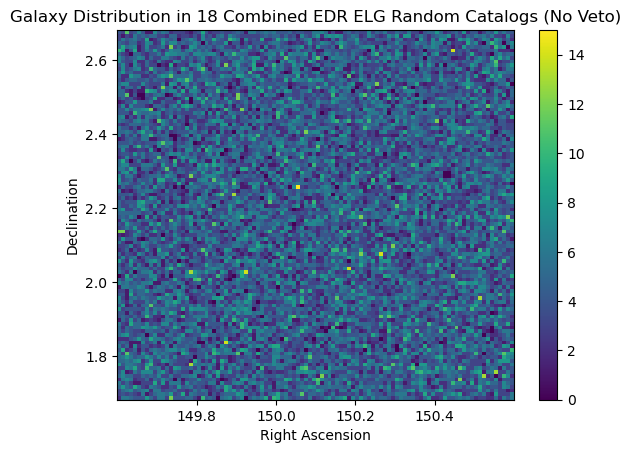

In [16]:
cut2 = elgEDRnoveto
ra1 = 150.1
dec1 = 2.182
stepsize = 0.01
sidelength = 0.5
nsteps = int(sidelength/stepsize)
#cut2 = randoms1[(randoms1['RA'] > ra1-nsteps*stepsize)&(randoms1['RA']<ra1+nsteps*stepsize)&(randoms1['DEC']>dec1-nsteps*stepsize)&(randoms1['DEC']<dec1+nsteps*stepsize)]
hist1,binsy,binsx = np.histogram2d(cut2['DEC'],cut2['RA'],bins=2*nsteps)
fig, ax = plt.subplots(1)
pc = ax.pcolormesh(binsx,binsy,hist1)
cbar = plt.colorbar(pc)
plt.xlabel("Right Ascension")
plt.ylabel("Declination")
plt.title("Galaxy Distribution in 18 Combined EDR ELG Random Catalogs (No Veto)")
plt.savefig("figsholes/elgEDRnoveto.png")

In [ ]:
#try on "noveto" ELGs
ra1 = 150.1
dec1 = 2.182
stepsize = 0.01
sidelength = 0.5
nsteps = int(sidelength/stepsize)
table5 = []
y1dir = '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/'
for i in np.arange(18):
    efile = y1dir + 'ELG_LOPnotqso_'+str(i)+'_full_noveto.ran.fits'
    sp = Table(fitsio.read(efile))
    spcut = sp[(sp['RA'] > ra1-nsteps*stepsize)&(sp['RA']<ra1+nsteps*stepsize)&(sp['DEC']>dec1-nsteps*stepsize)&(sp['DEC']<dec1+nsteps*stepsize)]
    table5.append(spcut)

elgY1noveto = vstack(table5)

In [ ]:
cut2 = elgY1noveto
ra1 = 150.1
dec1 = 2.182
stepsize = 0.01
sidelength = 0.5
nsteps = int(sidelength/stepsize)
#cut2 = randoms1[(randoms1['RA'] > ra1-nsteps*stepsize)&(randoms1['RA']<ra1+nsteps*stepsize)&(randoms1['DEC']>dec1-nsteps*stepsize)&(randoms1['DEC']<dec1+nsteps*stepsize)]
hist1,binsy,binsx = np.histogram2d(cut2['DEC'],cut2['RA'],bins=2*nsteps)
fig, ax = plt.subplots(1)
pc = ax.pcolormesh(binsx,binsy,hist1)
cbar = plt.colorbar(pc)
plt.xlabel("Right Ascension")
plt.ylabel("Declination")
plt.title("Galaxy Distribution in 18 Combined Y1 ELG Random Catalogs (No Veto)")
plt.savefig("figsholes/elgY1noveto.png")